## 2.6 Componente temporal

### 2.6.1 Validación de fechas, frecuencia y cobertura

Se analiza `close` por activo exclusivamente en DEVELOPMENT, desde **2020-08-11 06:00 UTC hasta 2025-07-01 18:00 UTC**, según la apertura de las velas. Las fechas se interpretan como ISO 8601 con zona UTC; se verifica que las aperturas estén alineadas a horas enteras. La frecuencia nominal es horaria, pero el calendario observado presenta huecos. Se conserva una rejilla horaria con valores ausentes, sin comprimir el tiempo ni interpolar precios.

| Activo | Horas observadas | Horas esperadas | Ausencias | Cierres irregulares | Fechas duplicadas |
| --- | --- | --- | --- | --- | --- |
| BNBUSDT | 42833 | 42853 | 20 | 6 | 0 |
| BTCUSDT | 42833 | 42853 | 20 | 6 | 0 |
| ETHUSDT | 42833 | 42853 | 20 | 6 | 0 |
| SOLUSDT | 42833 | 42853 | 20 | 5 | 0 |
| XRPUSDT | 42833 | 42853 | 20 | 5 | 0 |

La cobertura de timestamps es **99,9533 %** por activo. Las 20 horas ausentes no incluyen los cierres irregulares: estos son registros presentes cuyo cierre temporal no coincide con el final convencional de la hora. Para los cálculos de esta sección se enmascaran esos cierres, manteniendo los archivos originales. Por ello, la cobertura analítica válida es ligeramente menor que la cobertura de timestamps. Una fecha repetida entre activos es esperada; la unicidad se verifica dentro de cada activo.

### 2.6.2 Series completas y agregaciones

Los paneles por activo muestran toda la serie horaria de DEVELOPMENT, el último cierre de cada día completo y medias semanales y mensuales. Un día completo requiere 24 cierres horarios válidos. Las medias semanales y mensuales utilizan las observaciones válidas disponibles; los periodos con huecos o en los extremos pueden ser parciales. Estas agregaciones son descriptivas y no se introducen como entradas de predicción.

Las escalas de precio se mantienen separadas por activo, en USDT por unidad. Esto permite observar tendencias y fluctuaciones sin interpretar las diferencias de precio nominal entre criptomonedas como diferencias de riesgo.

### 2.6.3 Ciclos de calendario y descomposición

Se presentan boxplots de `close` por hora UTC, día de la semana y mes. Los puntos extremos se ocultan solo para facilitar la lectura; no se eliminan de los cálculos. Estos gráficos mezclan años y niveles de tendencia: una diferencia entre meses no demuestra una estacionalidad repetible. Los patrones por hora o día tampoco deben confundirse con una señal predictiva validada.

Se aplica [STL robusto](https://www.statsmodels.org/stable/generated/statsmodels.tsa.seasonal.STL.html) al logaritmo del cierre diario, con periodo de **7 días**. Se utiliza el tramo diario continuo más largo, seleccionado por cobertura y no por resultados: **2023-03-25 a 2025-06-30, 829 días**, común a los cinco activos. No se rellenan huecos. La descomposición separa tendencia, componente semanal y residuo; no evalúa ciclos horarios o anuales.

Como resumen descriptivo se calcula la fuerza semanal: máximo entre cero y uno menos la varianza del residuo dividida por la varianza de la suma del residuo y el componente estacional. No es una prueba de significación ni una proporción de varianza explicada del precio completo.

| Activo | Fuerza semanal STL |
| --- | --- |
| BNBUSDT | 0.0016 |
| BTCUSDT | 0.0343 |
| ETHUSDT | 0.0000 |
| SOLUSDT | 0.0796 |
| XRPUSDT | 0.0537 |

Los valores entre 0 y 0,080 indican una componente semanal débil según este indicador y esta configuración. No justifican introducir automáticamente variables de calendario. STL utiliza información a ambos lados de cada punto y aquí es solo exploratorio: sus componentes calculados sobre todo el tramo no pueden trasladarse directamente a un predictor disponible en tiempo real.

### 2.6.4 Estacionariedad

Se muestran medias y varianzas móviles de `close` sobre 30 días completos, con ventanas hacia atrás; los huecos interrumpen su cálculo. Además, se aplican pruebas al logaritmo del cierre diario y a su primera diferencia dentro del mismo tramo continuo. El retorno diario es un diagnóstico derivado de `close`, no una nueva variable original ni un cambio del objetivo horario.

[ADF](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html) contrasta la hipótesis nula de raíz unitaria; se usa constante y selección AIC entre 0 y 14 rezagos diarios. [KPSS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html) contrasta estacionariedad alrededor de una constante, con selección automática de rezagos. Son pruebas con hipótesis distintas. Los p-valores de KPSS en los límites de la tabla se presentan como cotas; los valores numéricos de ADF inferiores a 0,0001 se muestran con esa cota, no como probabilidades exactamente nulas.

| Activo | Serie | n | p ADF | p KPSS |
| --- | --- | --- | --- | --- |
| BNBUSDT | log close | 829 | 0.8375 | ≤0.01 |
| BNBUSDT | Retorno diario | 828 | <0.0001 | ≥0.10 |
| BTCUSDT | log close | 829 | 0.8571 | ≤0.01 |
| BTCUSDT | Retorno diario | 828 | <0.0001 | ≥0.10 |
| ETHUSDT | log close | 829 | 0.3622 | ≤0.01 |
| ETHUSDT | Retorno diario | 828 | <0.0001 | ≥0.10 |
| SOLUSDT | log close | 829 | 0.5509 | ≤0.01 |
| SOLUSDT | Retorno diario | 828 | <0.0001 | ≥0.10 |
| XRPUSDT | log close | 829 | 0.8778 | ≤0.01 |
| XRPUSDT | Retorno diario | 828 | <0.0001 | ≥0.10 |

En los cinco activos, ADF no rechaza raíz unitaria en el nivel logarítmico y KPSS rechaza estacionariedad alrededor de una constante al 5 %. En los retornos diarios, ADF rechaza raíz unitaria y KPSS no rechaza su hipótesis nula. El patrón es compatible con mayor estabilidad del retorno que del nivel en este tramo, pero no demuestra independencia, varianza constante ni estacionariedad durante todo DEVELOPMENT. Las pruebas son exploratorias, sin selección automática de transformaciones; cambios estructurales y la especificación determinista pueden afectar sus conclusiones.

### 2.6.5 Dependencia y correlaciones con rezagos

ACF y PACF se calculan hasta 30 rezagos **diarios** sobre las dos series del tramo continuo. La ACF del nivel logarítmico muestra persistencia y decaimiento lento; en retornos la dependencia lineal es mucho menor. Las curvas no incluyen bandas inferenciales ni constituyen una prueba de independencia. La ACF del nivel potencialmente no estacionario se interpreta descriptivamente.

La relación con el objetivo se examina mediante Pearson y Spearman entre `close(s-k)` y la volatilidad futura etiquetada en s, para k = 0, 1, 6, 12, 24, 48 y 168 **horas**. El objetivo utiliza 24 retornos horarios futuros, divisor 24 y escala porcentual. Solo se emparejan observaciones válidas mediante desplazamientos sobre el calendario completo. Los tamaños de muestra por rezago se guardan en la tabla; pueden diferir. No se usan rezagos futuros como entradas ni se elige aquí la ventana que maximiza una correlación.

Las asociaciones del precio en nivel pueden depender de tendencias y regímenes. Su interpretación no es causal ni demuestra capacidad predictiva fuera de muestra. Las etiquetas consecutivas comparten retornos futuros, lo que genera dependencia adicional entre observaciones.

### 2.6.6 Cambios de nivel, dispersión y deriva temporal

Las tendencias y varianzas móviles muestran cambios de nivel y dispersión. Se comparan por año las distribuciones de `close` y de la volatilidad futura mediante tamaño de muestra, media, desviación, mediana y percentiles 10 y 90. La tabla siguiente resume las medianas; 2020 y 2025 son periodos parciales, por lo que no equivalen a años completos.

| Activo | Variable | 2020 | 2021 | 2022 | 2023 | 2024 | 2025 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| BNBUSDT | close | 28.2091 | 379.3000 | 299.1000 | 248.8500 | 576.3000 | 642.3900 |
| BNBUSDT | target_pct | 0.6957 | 0.9254 | 0.5802 | 0.3640 | 0.5003 | 0.3807 |
| BTCUSDT | close | 12410.0500 | 47895.9900 | 23148.2050 | 27714.8700 | 64203.0950 | 96786.6800 |
| BTCUSDT | target_pct | 0.4600 | 0.7065 | 0.5176 | 0.3373 | 0.4554 | 0.3879 |
| ETHUSDT | close | 407.0300 | 2612.2400 | 1686.8500 | 1807.7950 | 3087.3100 | 2494.0200 |
| ETHUSDT | target_pct | 0.6747 | 0.8790 | 0.6959 | 0.3782 | 0.5411 | 0.6474 |
| SOLUSDT | close | 2.2224 | 38.6865 | 40.0250 | 22.1000 | 149.0850 | 152.0900 |
| SOLUSDT | target_pct | 1.5346 | 1.3455 | 0.9509 | 0.7685 | 0.7891 | 0.7646 |
| XRPUSDT | close | 0.2578 | 0.8873 | 0.4246 | 0.5016 | 0.5573 | 2.3048 |
| XRPUSDT | target_pct | 0.6816 | 1.0484 | 0.6810 | 0.5021 | 0.5506 | 0.7201 |

`close` se expresa en USDT y `target_pct` en porcentaje de volatilidad. Los cambios de medianas y dispersión evidencian diferencias marginales entre periodos. Un cambio en la distribución de `close` es una señal de cambio en las entradas; no basta para establecer covariate shift en sentido estricto, que además supone estabilidad de la relación condicional con el objetivo. Tampoco un cambio en la distribución del objetivo demuestra concept drift: este exige evidencia de cambio en la relación entre entradas y objetivo.

Se identifican variaciones descriptivas, no puntos de cambio formalmente estimados. No se atribuyen fluctuaciones a eventos externos sin un calendario documentado, ni se crean indicadores de feriados cuya pertinencia no haya sido justificada. La validación por periodos y el seguimiento posterior de errores permitirán evaluar si estos cambios afectan la capacidad predictiva.

### 2.6.7 Panel por activo

Los cinco activos comparten el calendario y el periodo analizado, pero difieren en niveles de precio, amplitud de fluctuaciones y distribución de volatilidad. Cada figura utiliza el mismo procedimiento y conserva su escala propia. Las magnitudes de variación absoluta de precios no son comparables directamente entre activos; la volatilidad en retornos permite una comparación en unidades comunes.

### 2.6.8 Consecuencias para el modelado

La partición y la validación deben respetar el orden cronológico, con ventanas crecientes o deslizantes dentro de DEVELOPMENT y el mismo corte para todos los activos. No se mezclan filas aleatoriamente. El gap debe comprobar la disponibilidad real de las etiquetas y excluir del entrenamiento cualquier horizonte objetivo que invada la validación; no basta con restar un número de filas a un panel de cinco activos.

Los rezagos y estadísticas móviles de entrada se construyen solo con información pasada. Las transformaciones aprendidas se ajustan dentro del entrenamiento de cada fold. La persistencia del precio no garantiza buena predicción de volatilidad, y la menor autocorrelación del retorno no implica ausencia de dependencia en su magnitud. Las diferencias entre periodos motivan informar desempeño por activo y por bloque temporal, además del promedio.

Esta exploración no cambia el horizonte de 24 horas, no selecciona una ventana definitiva y no entrena SVR, persistencia u otros modelos predictivos. TEST permanece reservado. La información temporal apoya el diseño de la validación, sin convertir los patrones retrospectivos en predictores disponibles en el pasado.

### 2.6.9 Reproducibilidad

El procedimiento está en `src/14_temporal_close.py`; las tablas se guardan en `outputs/tables/temporal_*.csv` y la trazabilidad en `outputs/tables/temporal_metadata.json`. Se verifica la conservación de DEVELOPMENT mediante SHA-256. Las pruebas, gráficos y descomposición no modifican los datos originales.

In [1]:
"""Componente temporal de close, solo DEVELOPMENT; no entrenamiento predictivo."""
from pathlib import Path
import hashlib,json,warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import statsmodels
from statsmodels.tsa.stattools import adfuller,kpss,acf,pacf
from statsmodels.tsa.seasonal import STL
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data/splits/development_80.csv').is_file())
def longest(s):
    valid=s.notna(); groups=(valid!=valid.shift()).cumsum()
    candidates=[v for _,v in s[valid].groupby(groups[valid])]
    return max(candidates,key=len)
def main():
    source=ROOT/'data/splits/development_80.csv';sha=hashlib.sha256(source.read_bytes()).hexdigest()
    df=pd.read_csv(source,usecols=['symbol','open_time','close_time','close'])
    for col in ['open_time','close_time']:df[col]=pd.to_datetime(df[col],utc=True,format='ISO8601')
    assert df.open_time.notna().all() and df.close_time.notna().all()
    assert df.open_time.eq(df.open_time.dt.floor('h')).all()
    grid=pd.date_range(df.open_time.min(),df.open_time.max(),freq='h')
    out=ROOT/'outputs/tables';figdir=ROOT/'book/_static/figures'
    audits=[];tests=[];cross=[];drift=[];season=[];series=[];acfrows=[]
    for symbol,g in df.groupby('symbol'):
        duplicates=int(g.duplicated('open_time').sum());assert duplicates==0
        g=g.set_index('open_time').reindex(grid)
        regular=g.close_time.eq(grid+pd.Timedelta(hours=1)-pd.Timedelta(milliseconds=1))
        c=g.close.where(regular);r=np.log(c).diff()
        target=100*r.rolling(24,min_periods=24).std(ddof=0).shift(-24)
        daily=c.resample('D').last().where(c.resample('D').count().eq(24))
        seg=longest(daily);logseg=np.log(seg)
        audits.append(dict(symbol=symbol,observed=int(g.close.notna().sum()),expected=len(grid),missing=int(g.close.isna().sum()),irregular_closes=int((g.close.notna()&~regular).sum()),duplicates=duplicates,coverage_pct=100*g.close.notna().mean(),daily_segment_start=str(seg.index.min()),daily_segment_end=str(seg.index.max()),daily_segment_n=len(seg)))
        for name,s in [('log_close',logseg),('daily_log_return',logseg.diff().dropna())]:
            a=adfuller(s,maxlag=14,regression='c',autolag='AIC')
            with warnings.catch_warnings(record=True) as w:
                warnings.simplefilter('always');k=kpss(s,regression='c',nlags='auto')
            tests.append(dict(symbol=symbol,series=name,n=len(s),adf_stat=a[0],adf_p=a[1],adf_lags=a[2],kpss_stat=k[0],kpss_p=k[1],kpss_lags=k[2],kpss_warning=' | '.join(str(v.message) for v in w)))
        stl=STL(logseg,period=7,robust=True).fit()
        strength=max(0,1-np.var(stl.resid)/np.var(stl.seasonal+stl.resid))
        season.append(dict(symbol=symbol,weekly_strength=strength,period_days=7,n=len(seg)))
        for lag in [0,1,6,12,24,48,168]:
            pairs=pd.DataFrame({'x':c.shift(lag),'y':target}).dropna()
            cross.append(dict(symbol=symbol,lag_hours=lag,n=len(pairs),pearson=pairs.x.corr(pairs.y),spearman=pairs.x.corr(pairs.y,method='spearman')))
        for year in sorted(set(grid.year)):
            for name,s in [('close',c),('target_pct',target)]:
                v=s[s.index.year==year].dropna()
                drift.append(dict(symbol=symbol,year=year,variable=name,n=len(v),mean=v.mean(),std=v.std(),q10=v.quantile(.1),median=v.median(),q90=v.quantile(.9)))
        series.append(pd.DataFrame({'symbol':symbol,'time':daily.index,'daily_close':daily.to_numpy()}))
        fig,ax=plt.subplots(4,3,figsize=(18,18),constrained_layout=True)
        a=ax.flat
        a[0].plot(c.index,c,lw=.35);a[0].set_title('Serie horaria · close (USDT)')
        a[1].plot(daily.index,daily,lw=.5,label='Diario, 24 cierres válidos')
        for freq,label in [('W-SUN','Media semanal'),('MS','Media mensual')]:
            v=c.resample(freq).mean();a[1].plot(v.index,v,label=label,lw=1)
        a[1].legend(fontsize=7);a[1].set_title('Agregaciones descriptivas · USDT')
        for axis,key,labels,title in [(a[2],c.index.hour,range(24),'Hora UTC'),(a[3],c.index.dayofweek,range(7),'Día: 0=lunes'),(a[4],c.index.month,range(1,13),'Mes')]:
            axis.boxplot([c[key==k].dropna() for k in labels],tick_labels=list(labels),showfliers=False)
            axis.set_title('close por '+title+' · sin puntos extremos');axis.tick_params(axis='x',labelsize=7)
        a[5].plot(logseg.index,logseg,label='log close',lw=.5);a[5].plot(logseg.index,stl.trend,label='Tendencia STL');a[5].legend();a[5].set_title('STL semanal · tramo diario continuo')
        a[6].plot(logseg.index,stl.seasonal,label='Estacional',lw=.6);a[6].plot(logseg.index,stl.resid,label='Residuo',lw=.5,alpha=.6);a[6].legend();a[6].set_title('STL · unidades logarítmicas')
        a[7].plot(daily.index,daily.rolling(30,min_periods=30).mean(),label='Media 30 días')
        a[7].set_ylabel('USDT');other=a[7].twinx();other.plot(daily.index,daily.rolling(30,min_periods=30).var(),color='orange',label='Varianza');other.set_ylabel('Varianza USDT²');a[7].set_title('Media (azul) y varianza (naranja), hacia atrás')
        for s,label in [(logseg,'log close'),(logseg.diff().dropna(),'retorno diario')]:
            ac=acf(s,nlags=30,fft=True);pc=pacf(s,nlags=30,method='ywm')
            a[8].plot(range(31),ac,label=label);a[9].plot(range(31),pc,label=label)
            acfrows.extend(dict(symbol=symbol,series=label,lag_days=j,acf=ac[j],pacf=pc[j]) for j in range(31))
        a[8].set_title('ACF · rezagos diarios');a[9].set_title('PACF · rezagos diarios');a[8].legend();a[9].legend()
        own=pd.DataFrame(cross).query('symbol == @symbol');a[10].plot(own.lag_hours,own.pearson,marker='o',label='Pearson');a[10].plot(own.lag_hours,own.spearman,marker='o',label='Spearman');a[10].legend();a[10].set_title('close(s-k) vs volatilidad futura(s) · k horas')
        years=sorted(set(grid.year));a[11].boxplot([target[target.index.year==y].dropna() for y in years],tick_labels=years,showfliers=False);a[11].set_title('Objetivo por año · % · años extremos parciales')
        for axis in a:axis.grid(alpha=.15);axis.tick_params(axis='x',rotation=35)
        fig.suptitle(symbol+' · componente temporal · DEVELOPMENT',fontsize=17)
        fig.savefig(figdir/f'temporal_{symbol}.png',dpi=120);plt.close(fig)
    for name,rows in [('audit',audits),('stationarity',tests),('cross_lags',cross),('drift',drift),('seasonality',season),('acf',acfrows)]:pd.DataFrame(rows).to_csv(out/f'temporal_{name}.csv',index=False)
    pd.concat(series).to_csv(out/'temporal_daily.csv',index=False)
    assert sha==hashlib.sha256(source.read_bytes()).hexdigest()
    (out/'temporal_metadata.json').write_text(json.dumps({'source':str(source.relative_to(ROOT)),'sha256':sha,'start':str(grid.min()),'end':str(grid.max()),'test_read':False,'statsmodels':statsmodels.__version__,'target_ddof':0,'imputation':False},indent=2),encoding='utf-8')
    print(pd.DataFrame(audits).to_string(index=False));print(pd.DataFrame(tests).drop(columns='kpss_warning').to_string(index=False));print(pd.DataFrame(season).to_string(index=False))
if __name__=='__main__':main()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11284\2704035428.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a=adfuller(s,maxlag=14,regression='c',autolag='AIC')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11284\2704035428.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a=adfuller(s,maxlag=14,regression='c',autolag='AIC')


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11284\2704035428.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a=adfuller(s,maxlag=14,regression='c',autolag='AIC')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11284\2704035428.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a=adfuller(s,maxlag=14,regression='c',autolag='AIC')


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11284\2704035428.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a=adfuller(s,maxlag=14,regression='c',autolag='AIC')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11284\2704035428.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a=adfuller(s,maxlag=14,regression='c',autolag='AIC')


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11284\2704035428.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a=adfuller(s,maxlag=14,regression='c',autolag='AIC')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11284\2704035428.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a=adfuller(s,maxlag=14,regression='c',autolag='AIC')


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11284\2704035428.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a=adfuller(s,maxlag=14,regression='c',autolag='AIC')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11284\2704035428.py:36: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  a=adfuller(s,maxlag=14,regression='c',autolag='AIC')


 symbol  observed  expected  missing  irregular_closes  duplicates  coverage_pct       daily_segment_start         daily_segment_end  daily_segment_n
BNBUSDT     42833     42853       20                 6           0     99.953329 2023-03-25 00:00:00+00:00 2025-06-30 00:00:00+00:00              829
BTCUSDT     42833     42853       20                 6           0     99.953329 2023-03-25 00:00:00+00:00 2025-06-30 00:00:00+00:00              829
ETHUSDT     42833     42853       20                 6           0     99.953329 2023-03-25 00:00:00+00:00 2025-06-30 00:00:00+00:00              829
SOLUSDT     42833     42853       20                 5           0     99.953329 2023-03-25 00:00:00+00:00 2025-06-30 00:00:00+00:00              829
XRPUSDT     42833     42853       20                 5           0     99.953329 2023-03-25 00:00:00+00:00 2025-06-30 00:00:00+00:00              829
 symbol           series   n   adf_stat    adf_p  adf_lags  kpss_stat  kpss_p  kpss_lags
BNBUSDT    

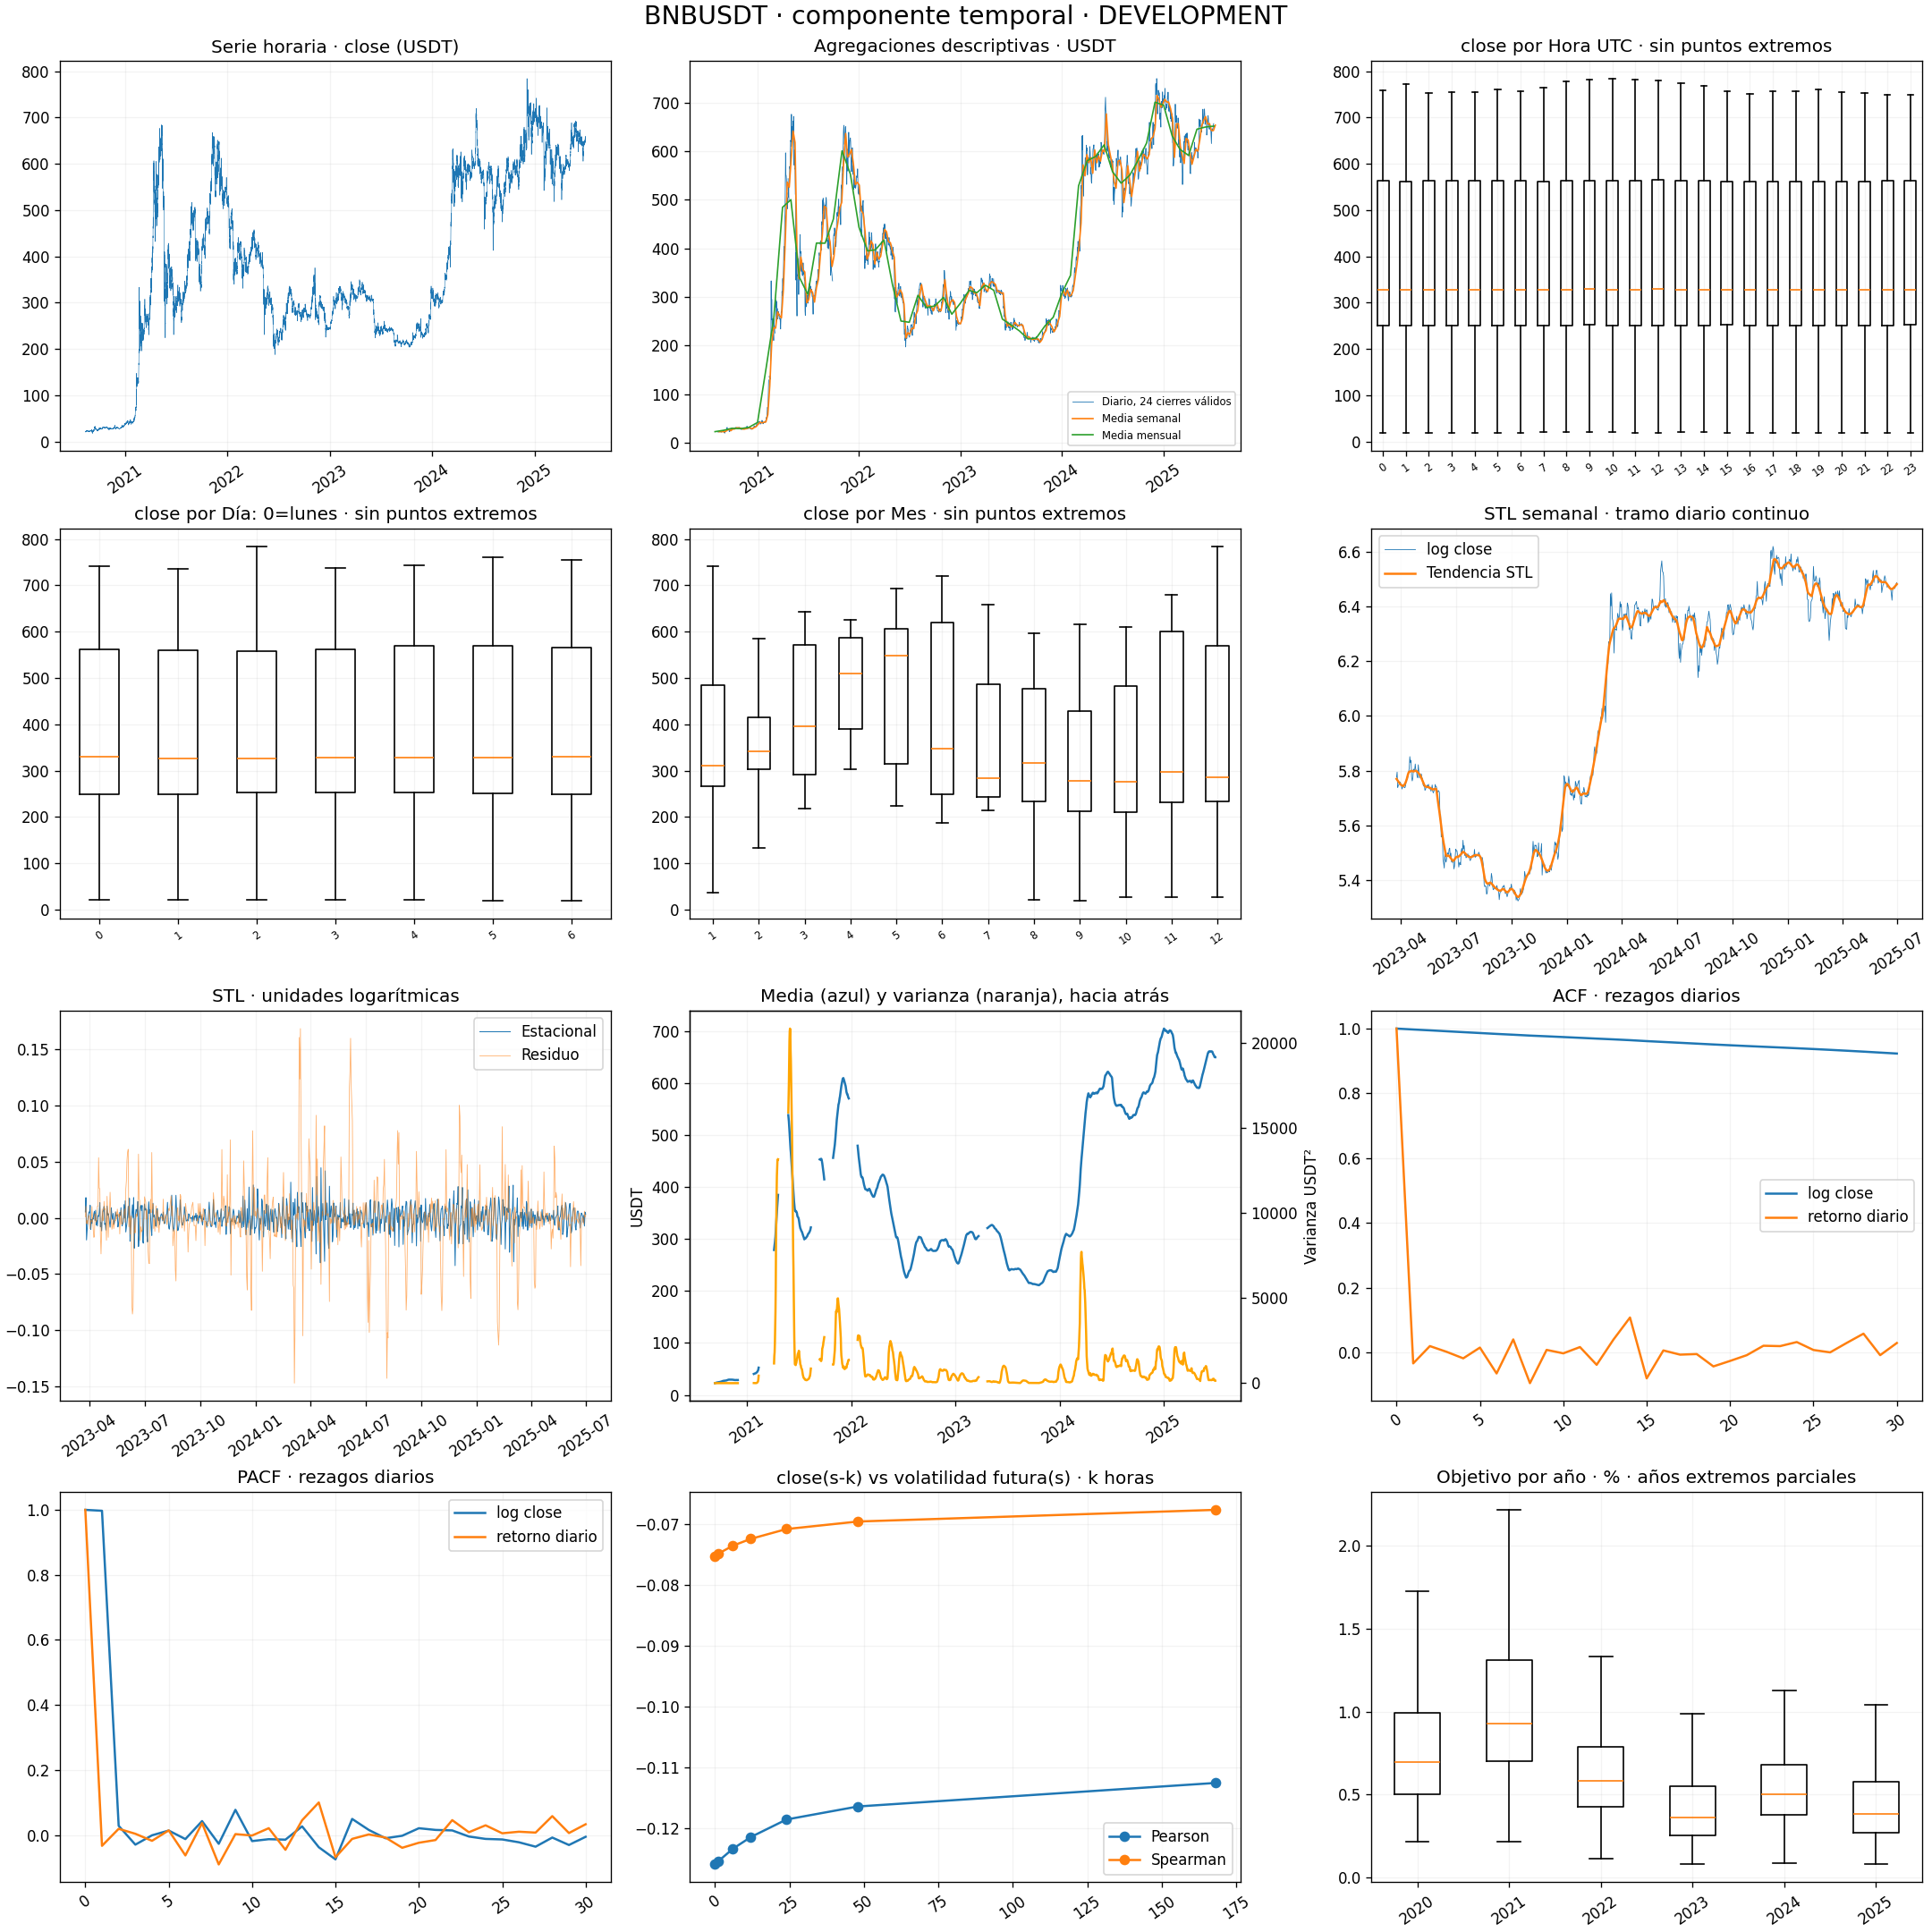

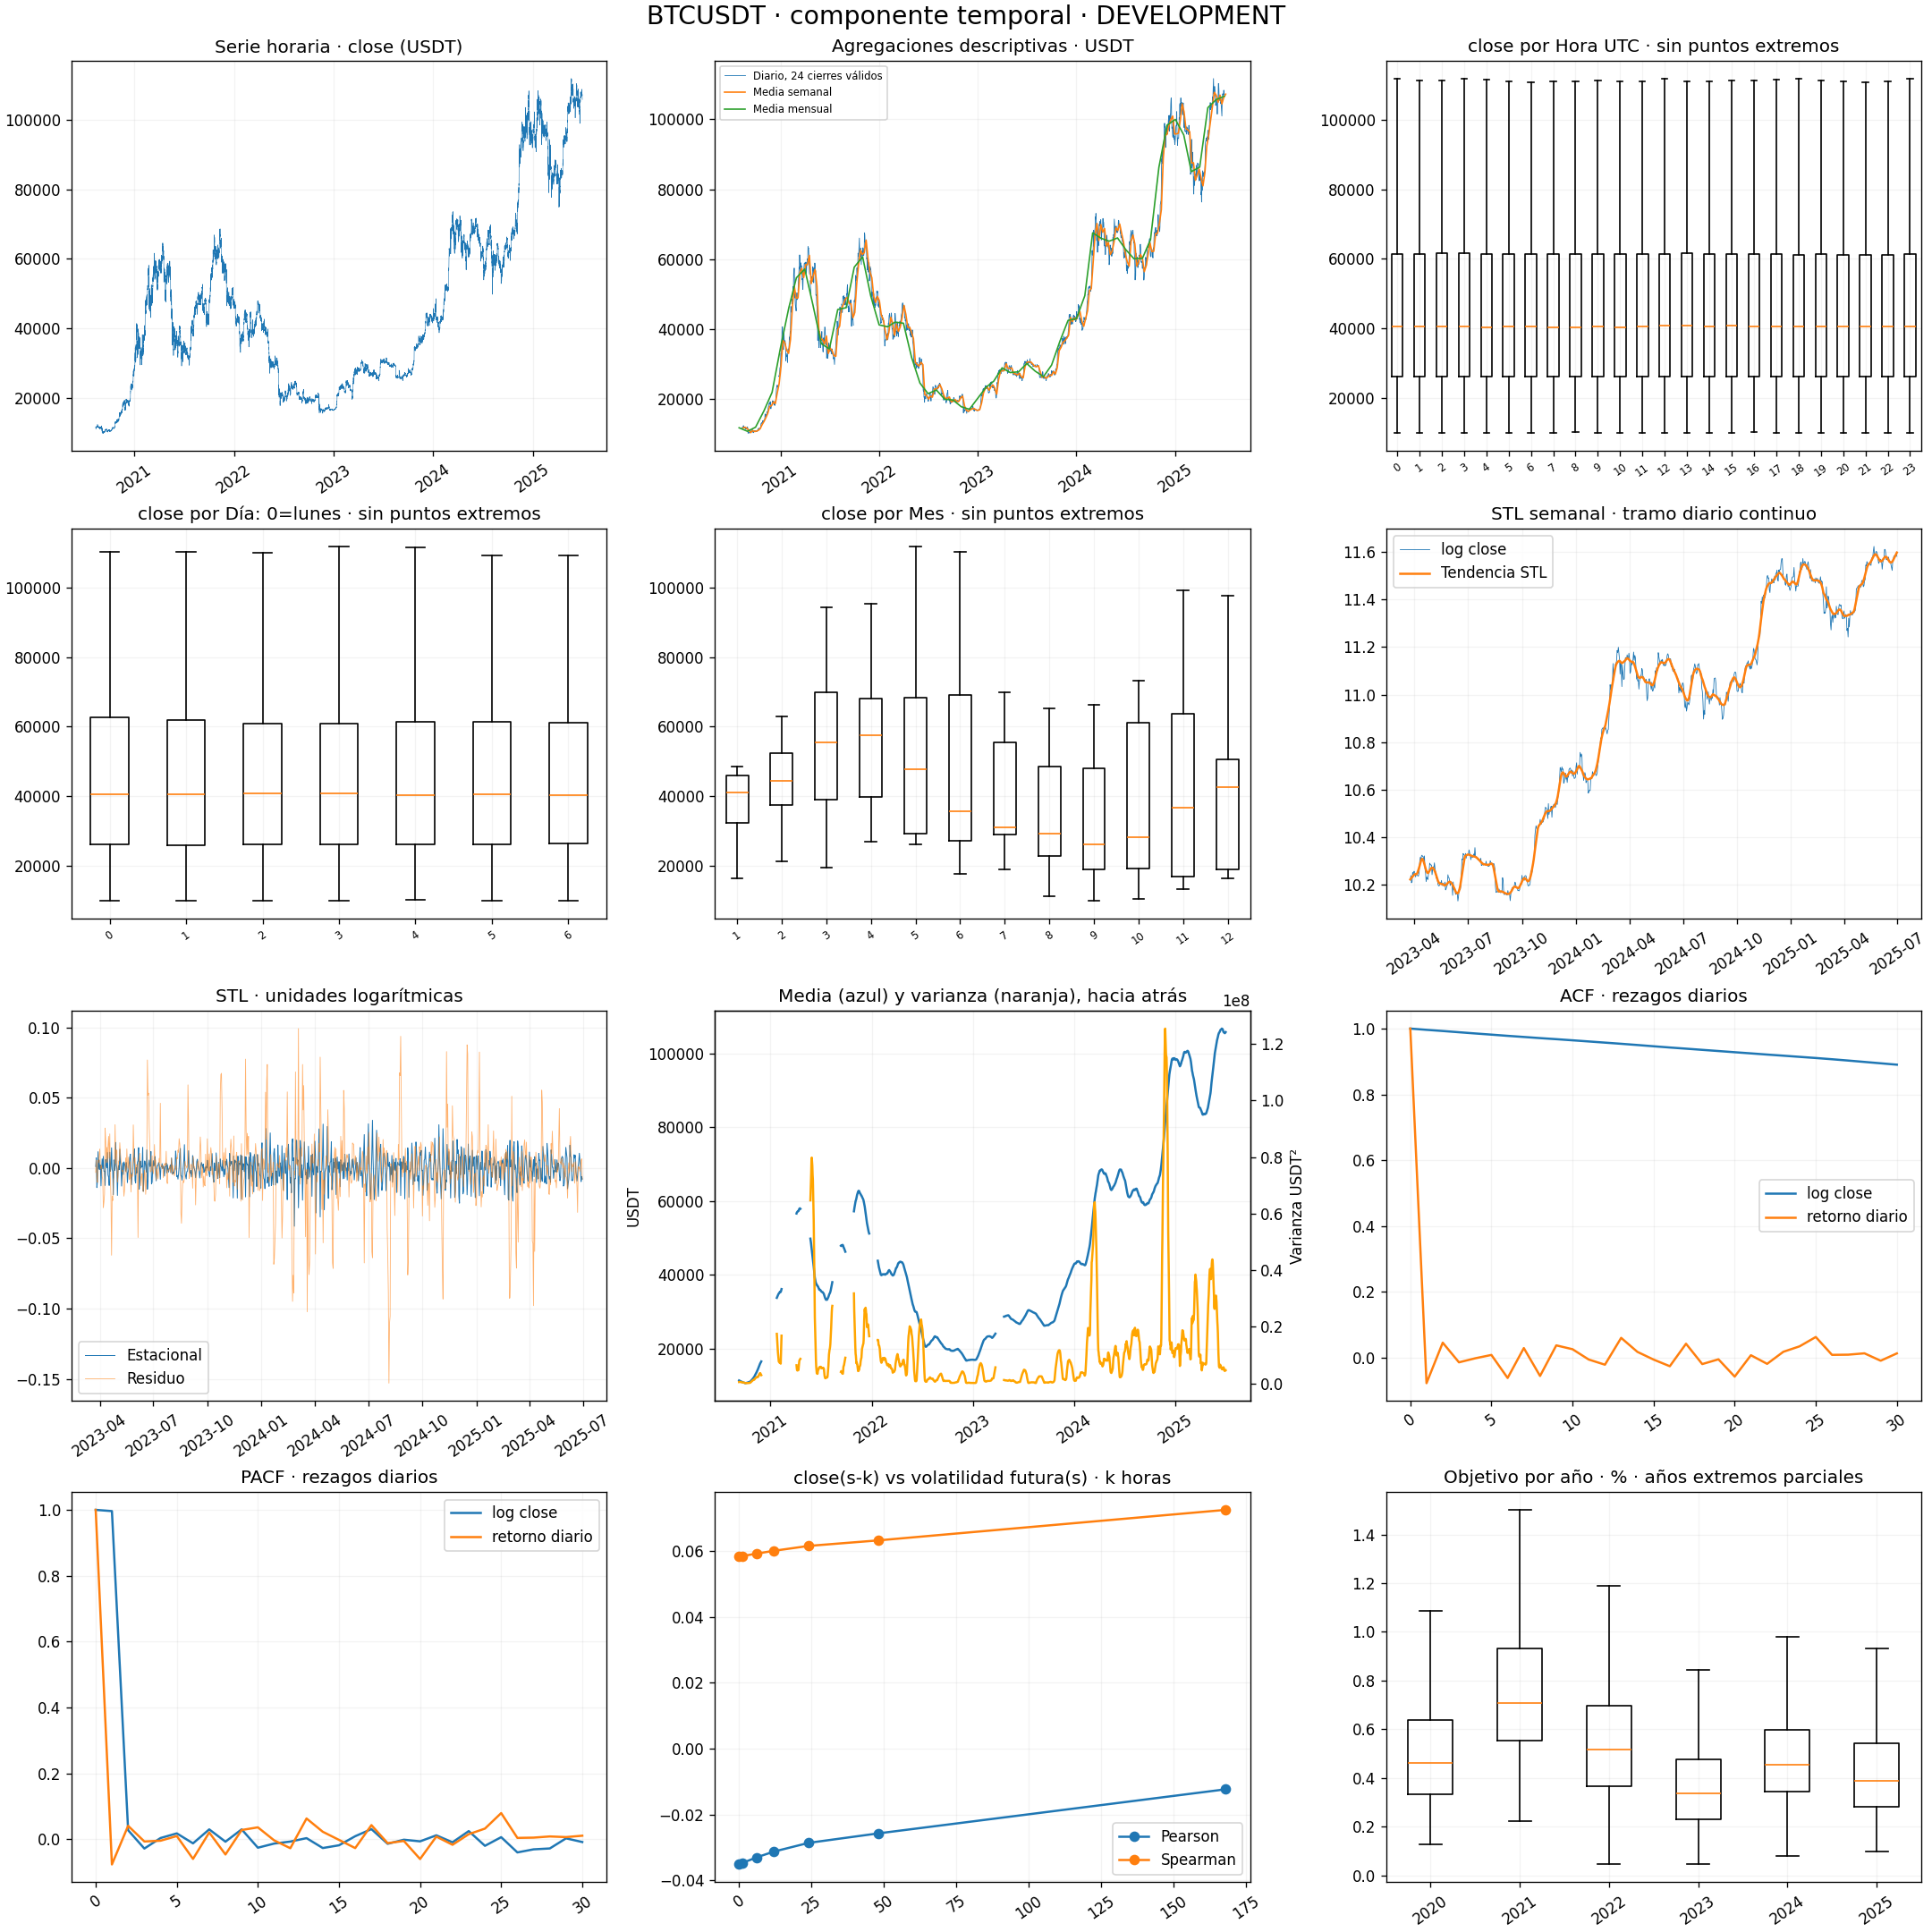

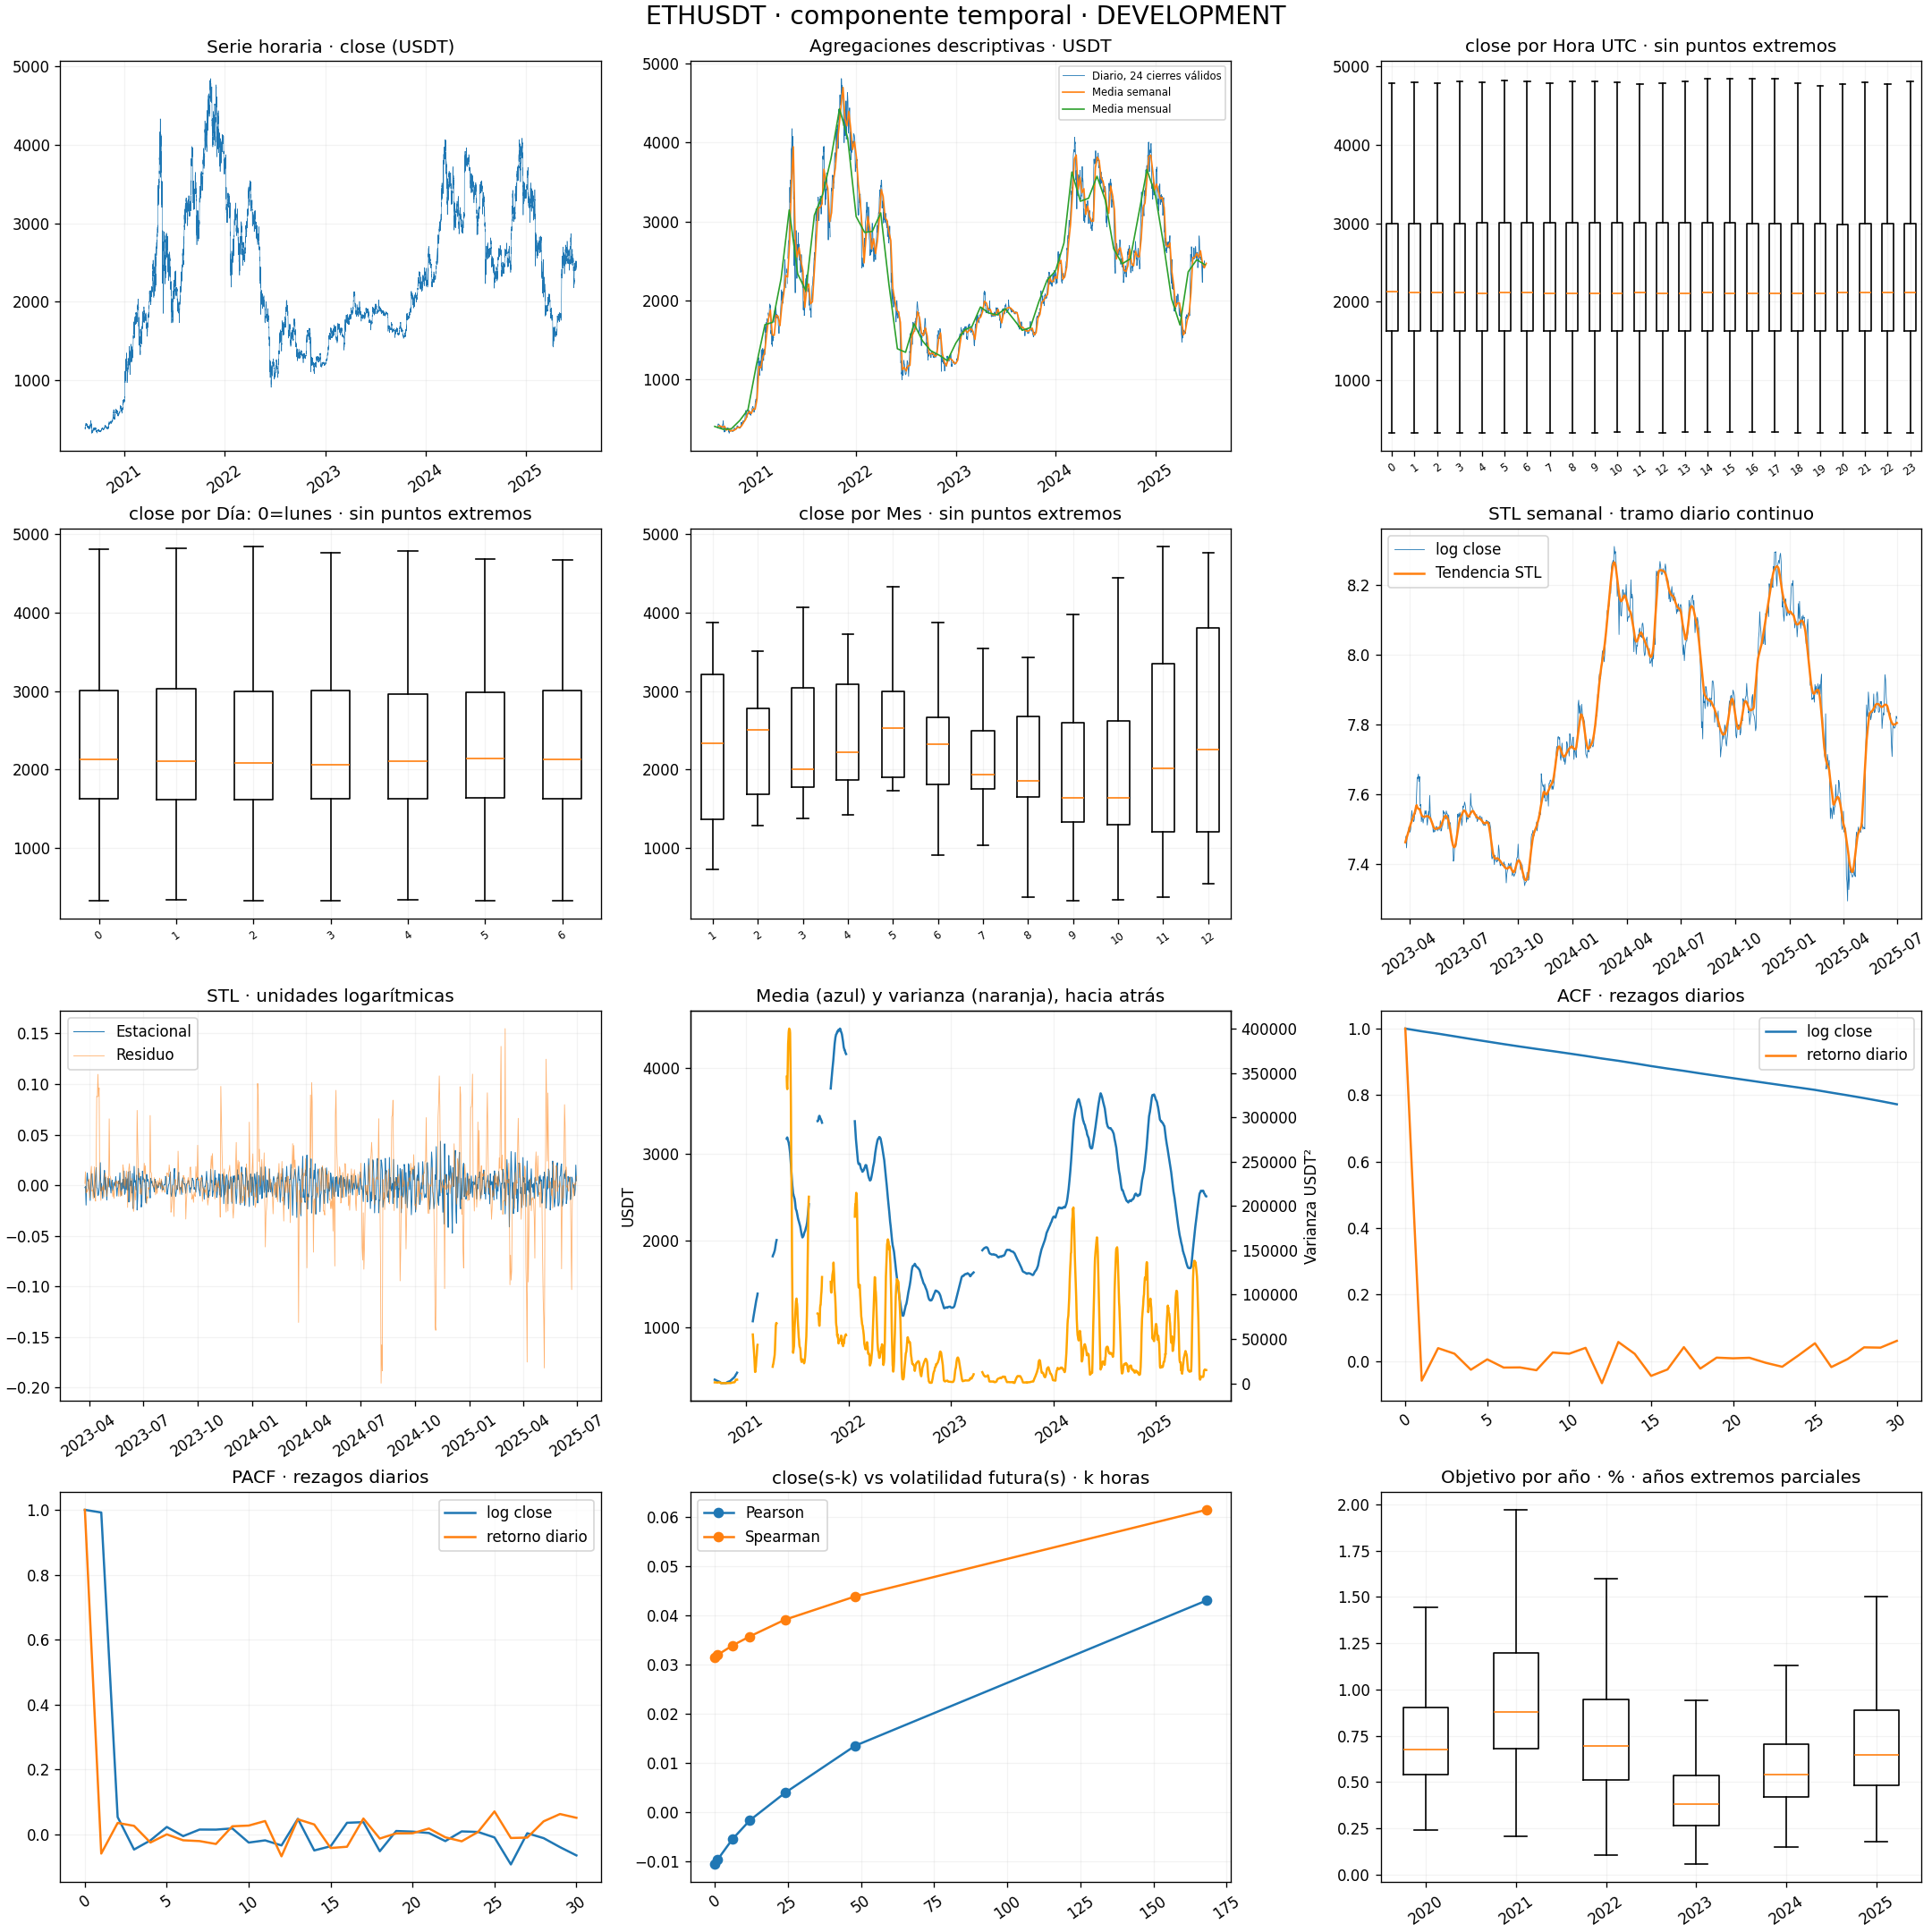

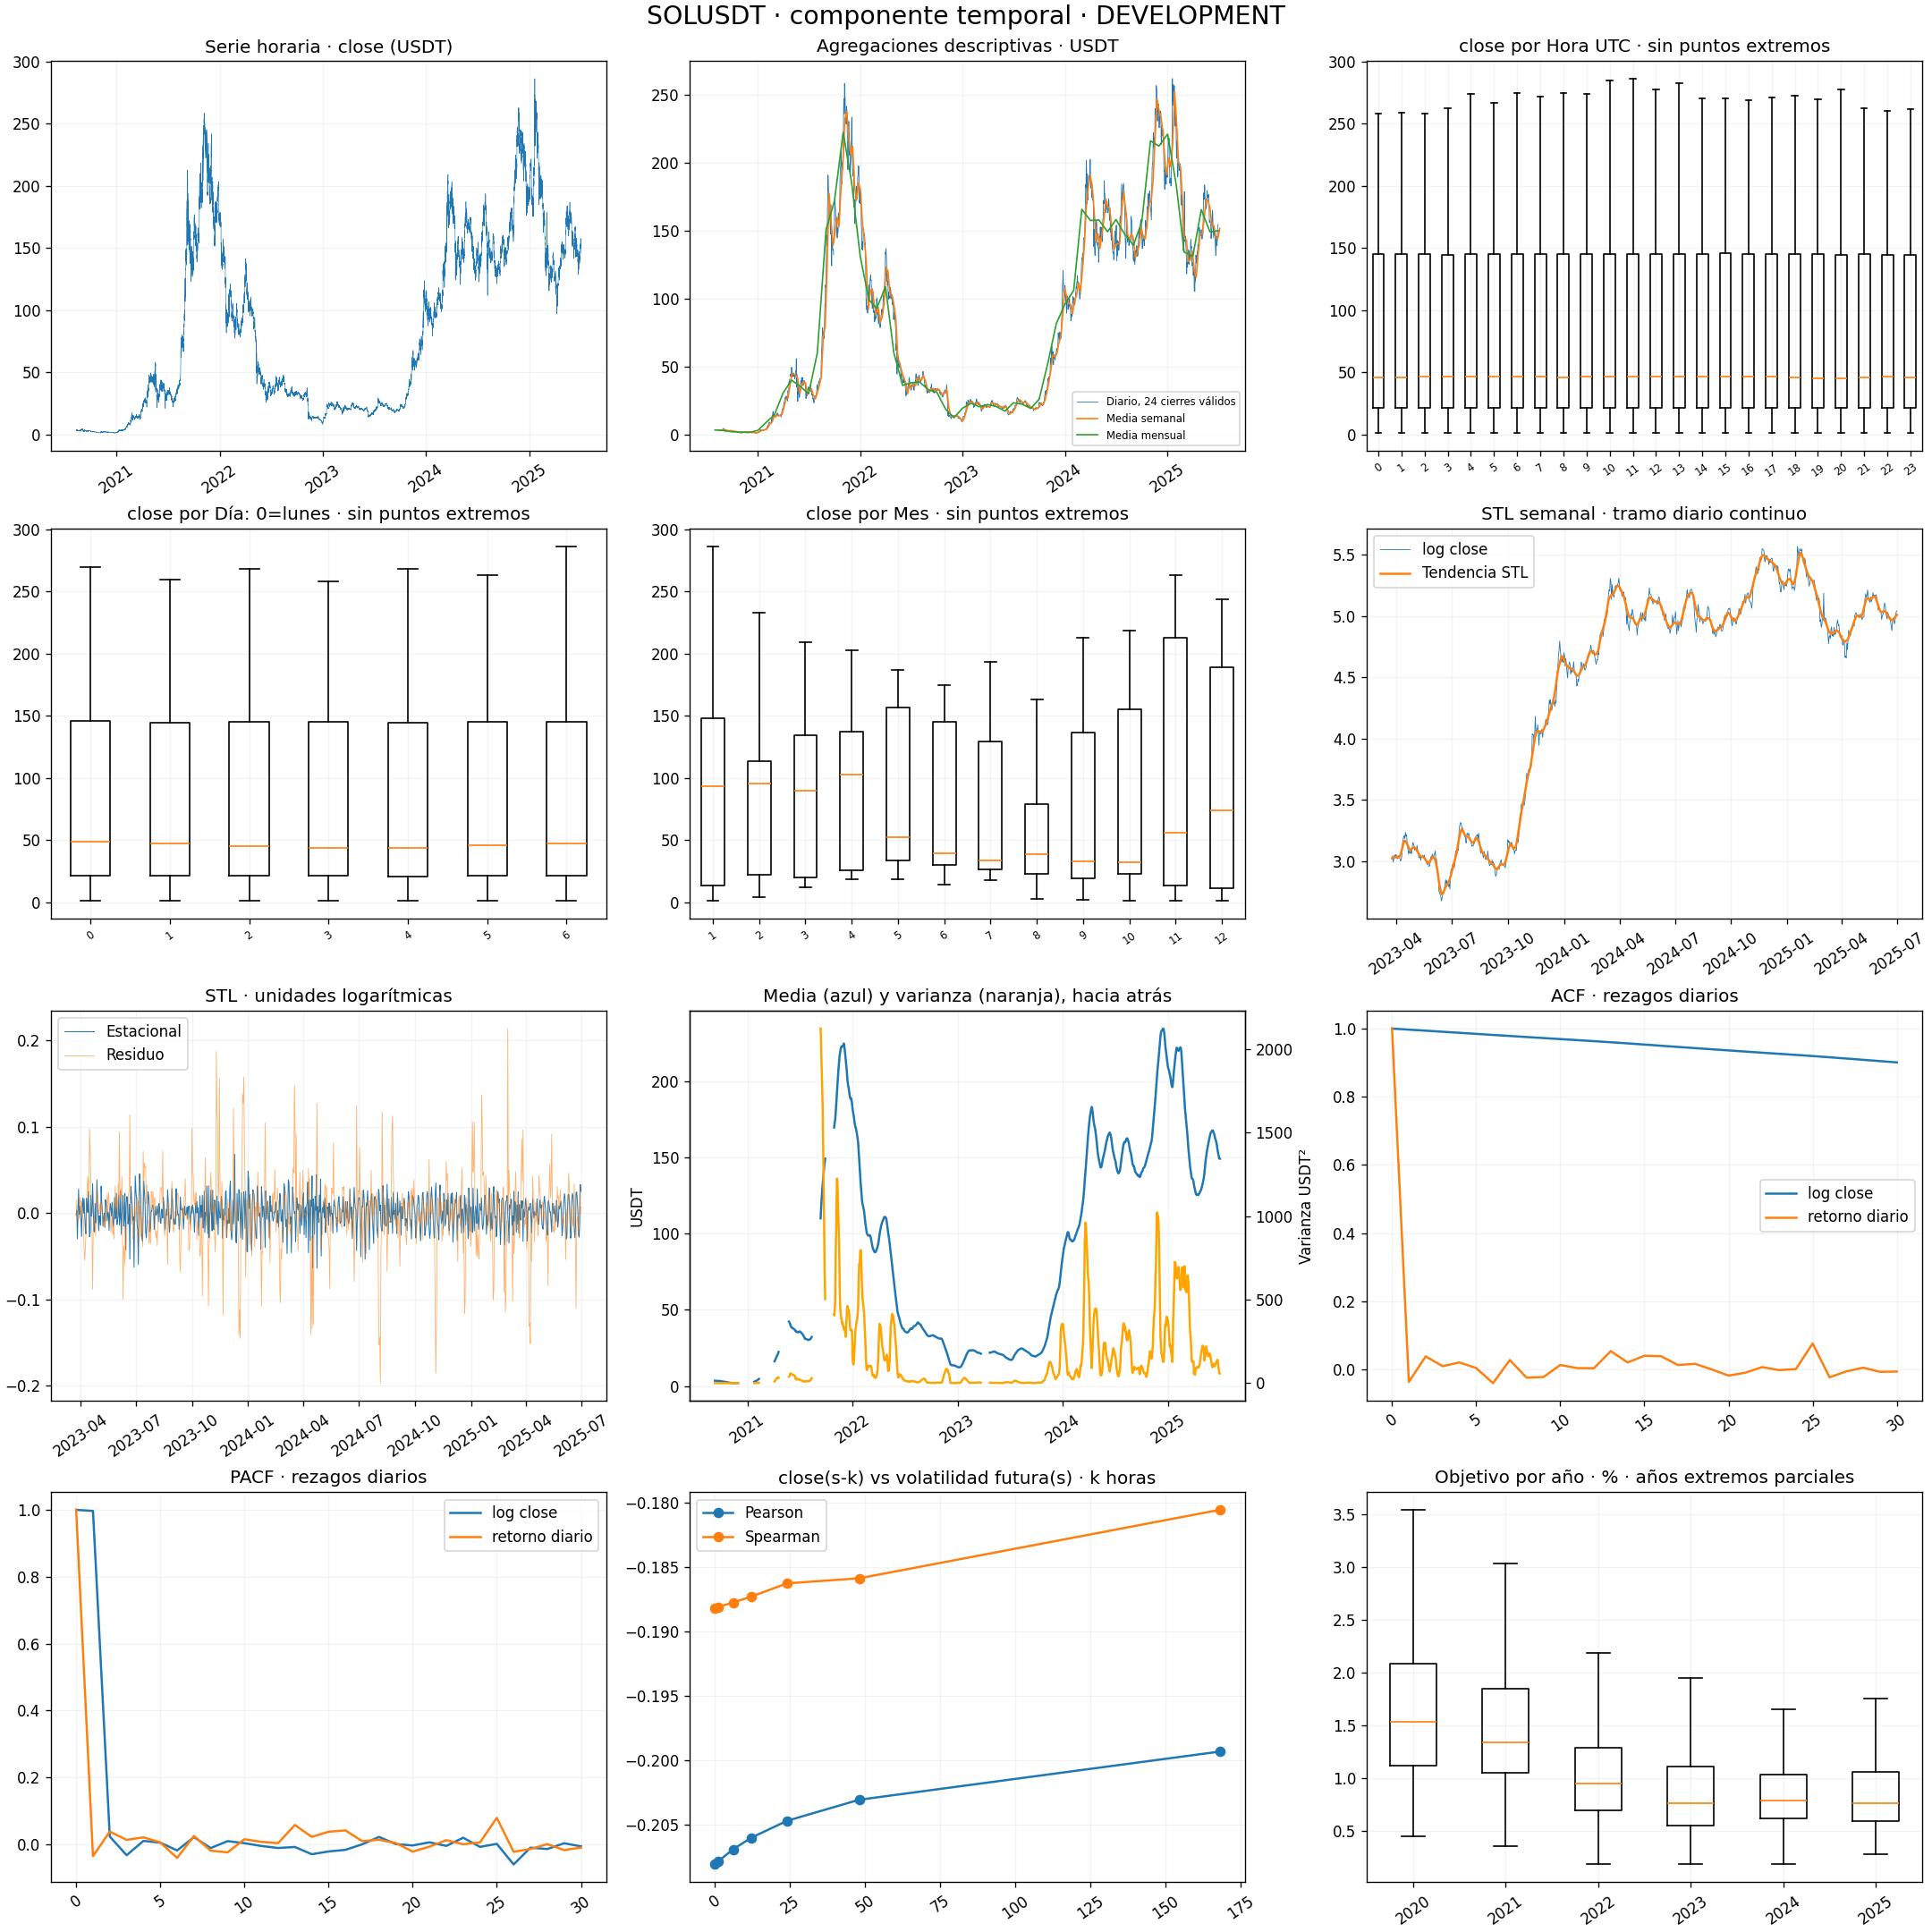

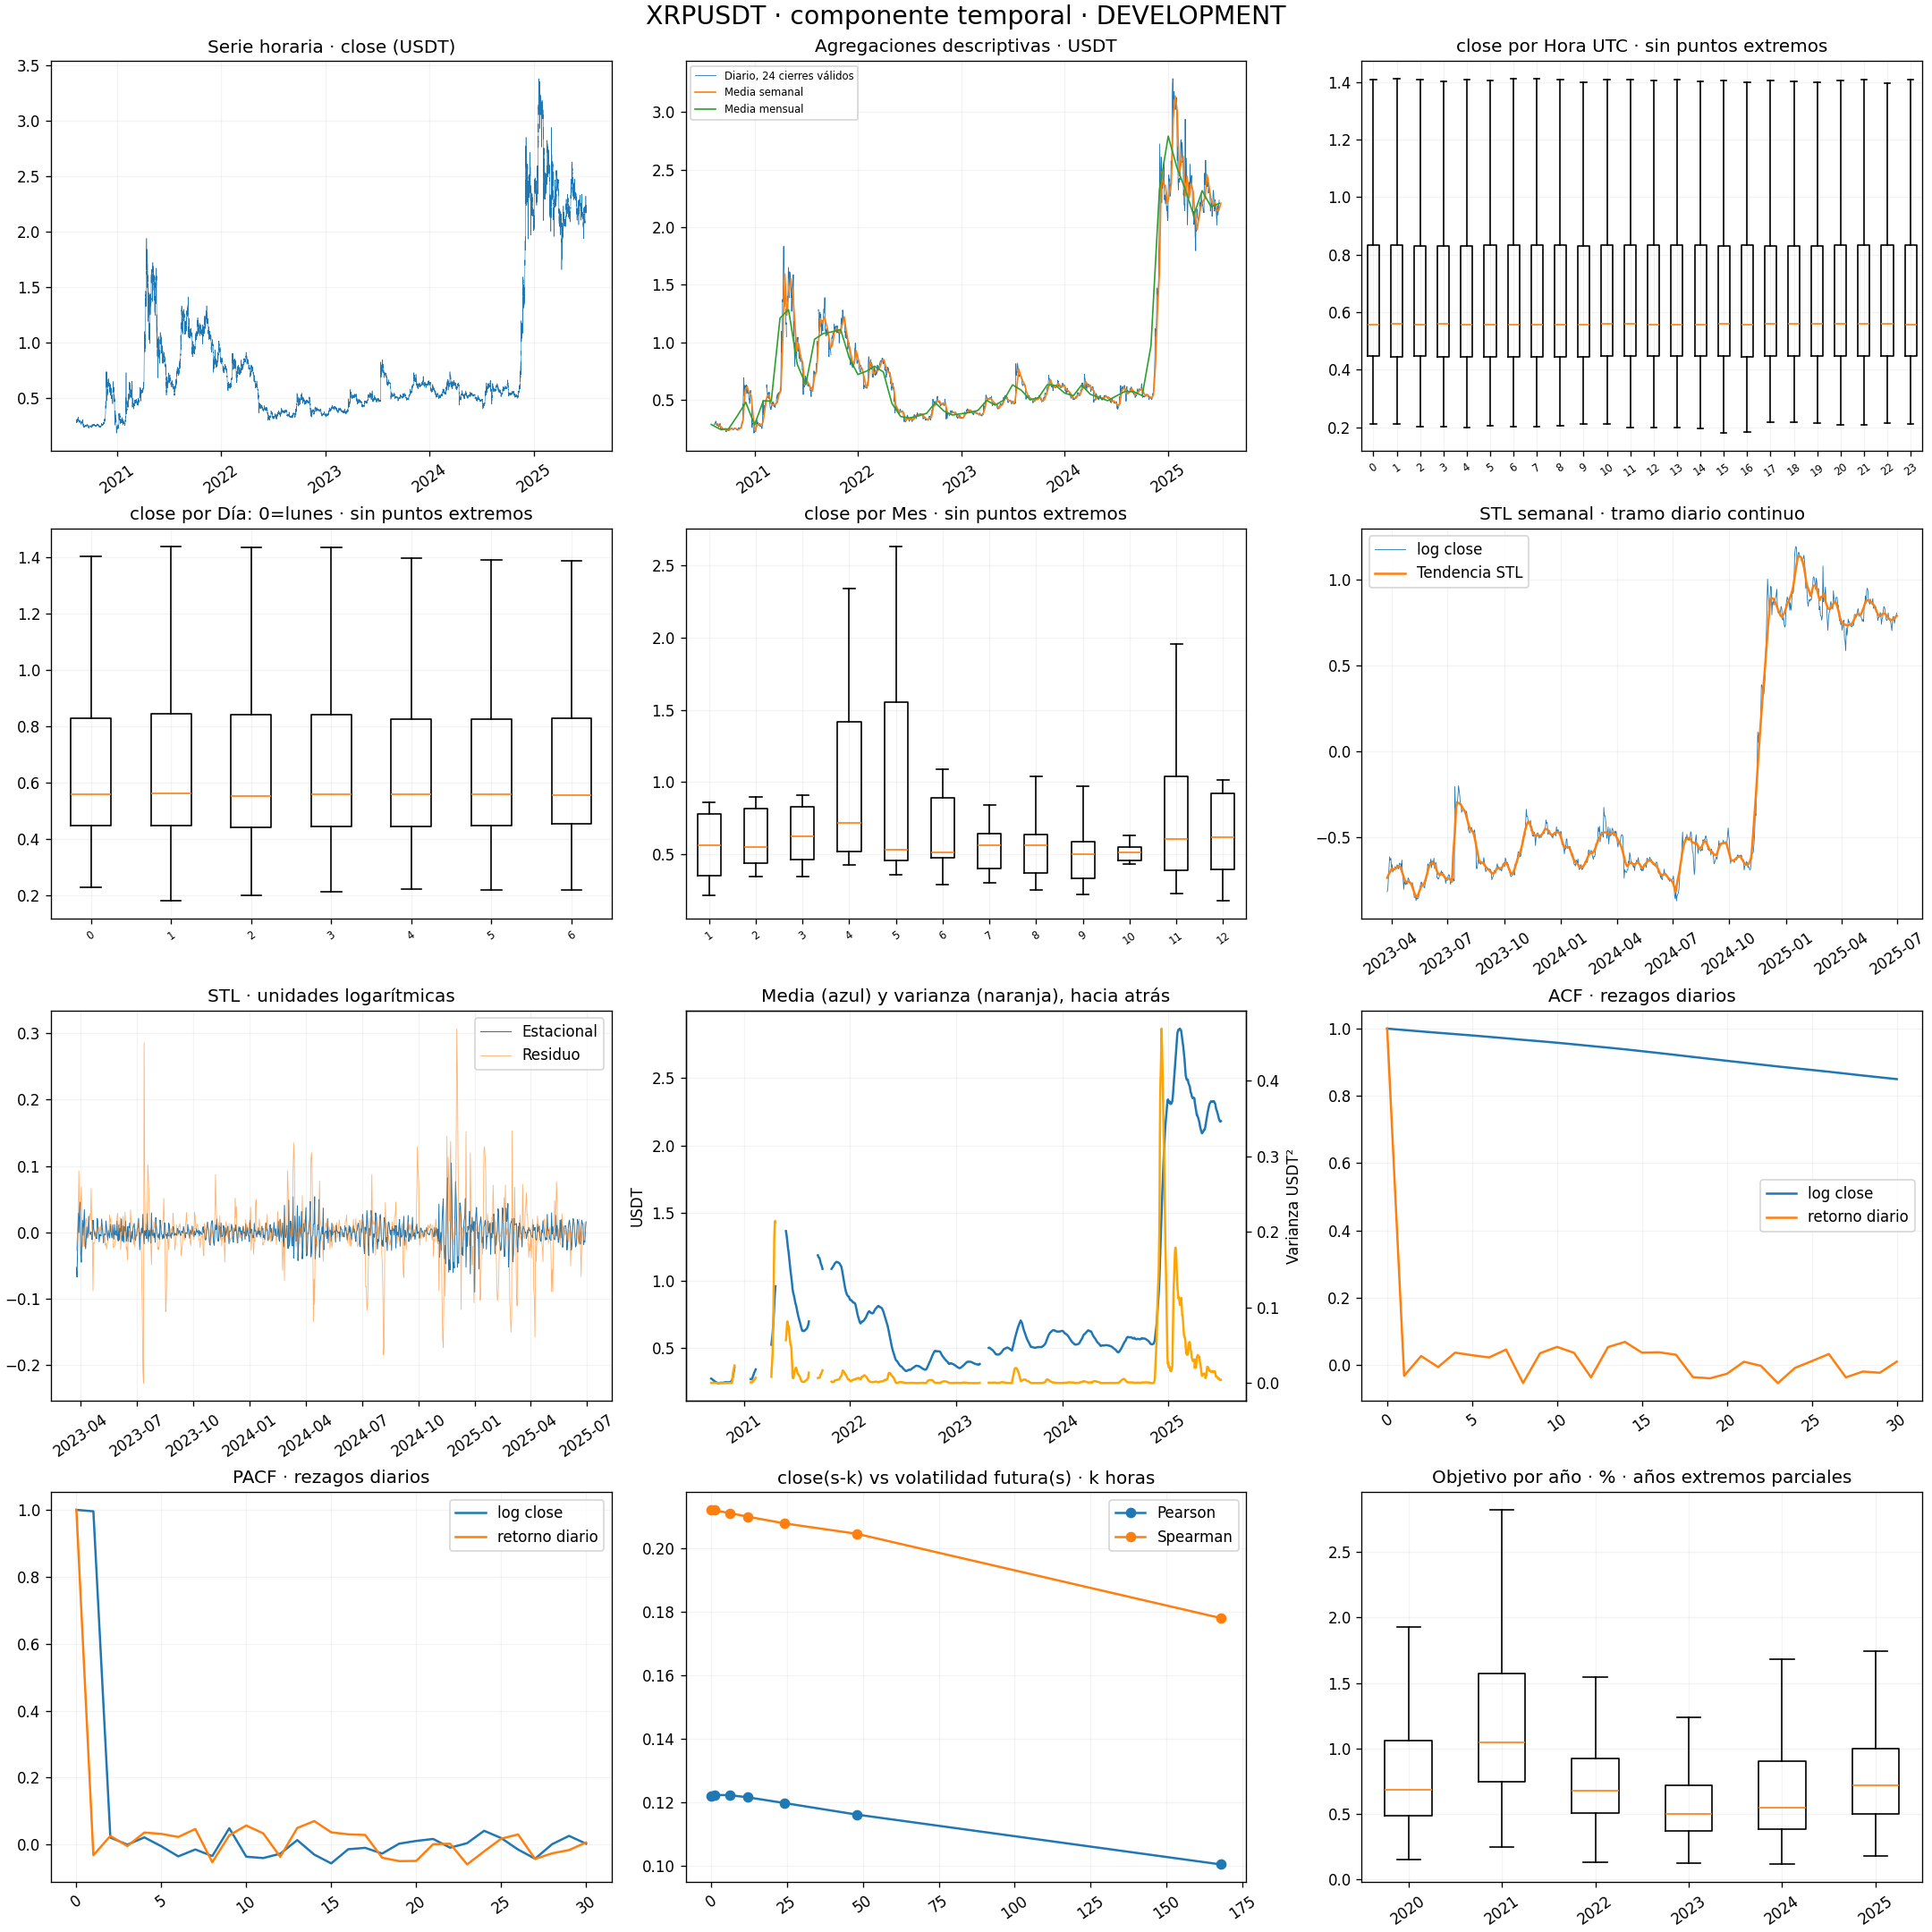

In [2]:
from IPython.display import display, Image
for p in sorted((ROOT/'book/_static/figures').glob('temporal_*.png')):
    display(Image(filename=str(p)))